## Import Library

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [36]:
df = pd.read_csv('../data/raw/health_insurance_origin.csv')

### Configs Display Notebooks (Optional)

In [37]:
# Format the float to 2 decimal places 
pd.set_option('display.float_format','{:.2f}'.format)

# Set the style of Seaborn
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)

## EDA

In [38]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 129.4 KB


In [40]:
# Check the shape(column, row) of dataset
df.shape

(1340, 10)

In [41]:
# check duplicated values
df.duplicated().sum()

# df.drop_duplicates(inplace=True) # incomment if you want to drop duplicates

np.int64(0)

In [42]:
# check the missing values (isna & isnull are the same)
df.isna().sum()
# df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [43]:
# Check the missing value in row
null_value = df[df.isna().any(axis=1)]
display(null_value)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
5,6,NaN,male,34.40,96,Yes,0,No,northwest,1137.47
6,7,NaN,male,37.30,86,Yes,0,No,northwest,1141.45
13,14,32.00,male,27.60,100,No,0,No,NaN,1252.41
14,15,40.00,male,28.70,81,Yes,0,No,NaN,1253.94
15,16,32.00,male,30.40,86,Yes,0,No,NaN,1256.30


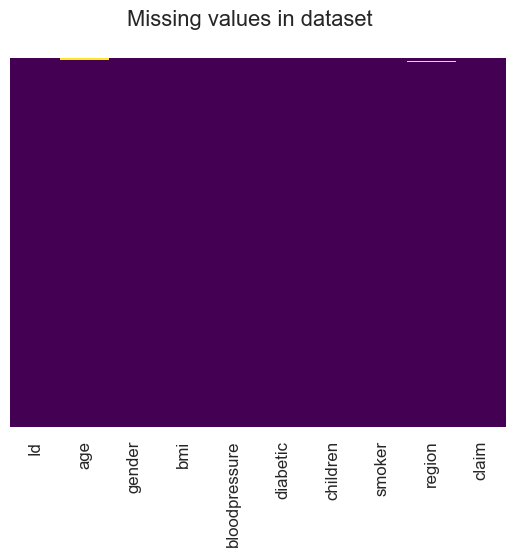

In [44]:
# Visualize the missing values using a heatmap
# yellow = missing value
# purple = not missing value
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.suptitle('Missing values in dataset')
plt.show()

In [45]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1340.00,1335.00,1340,1340.00,1340.00,1340,1340.00,1340,1337,1340.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,678,NaN,NaN,698,NaN,1066,443,NaN
mean,670.50,38.08,NaN,30.67,94.16,NaN,1.09,NaN,NaN,13252.75
std,386.97,11.10,NaN,6.11,11.43,NaN,1.21,NaN,NaN,12109.61
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,335.75,29.00,NaN,26.27,86.00,NaN,0.00,NaN,NaN,4719.68
50%,670.50,38.00,NaN,30.40,92.00,NaN,1.00,NaN,NaN,9369.61
75%,1005.25,47.00,NaN,34.70,99.00,NaN,2.00,NaN,NaN,16604.31


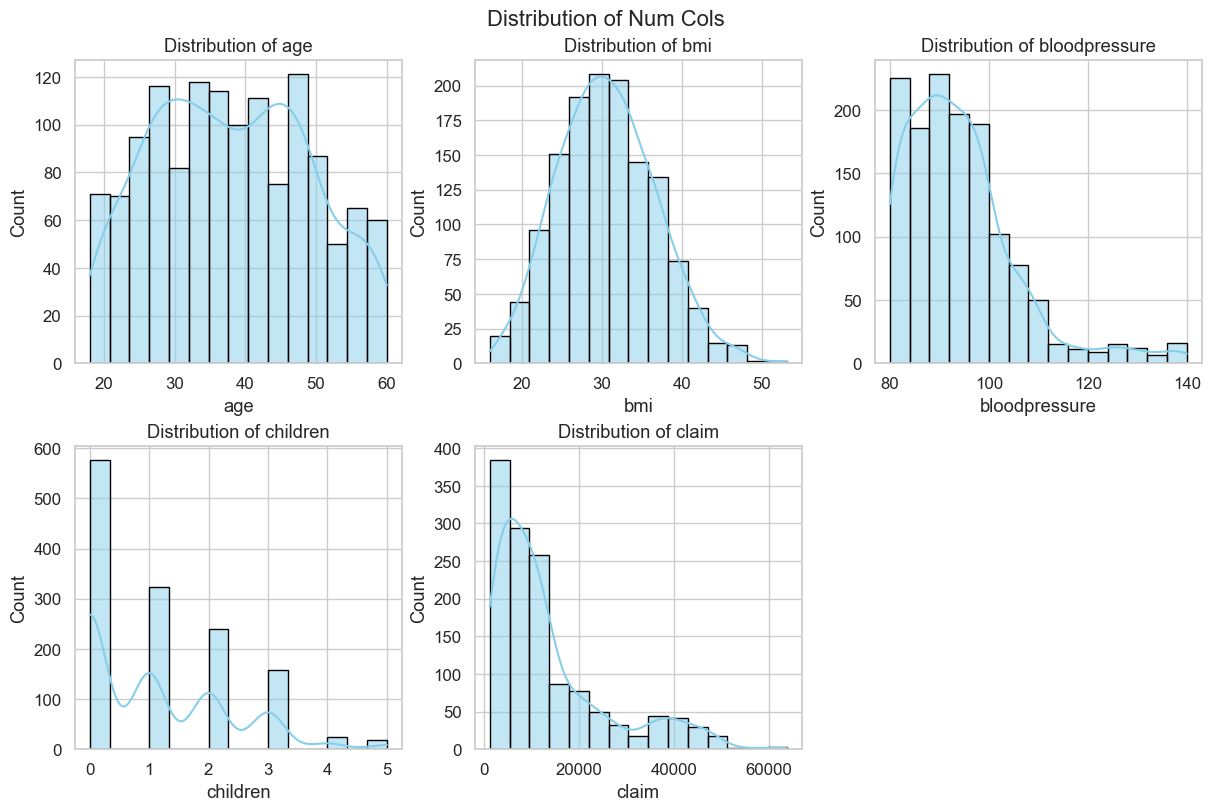

In [46]:
# Visualize the distribution numerical cols
numerical_cols = ['age', 'bmi', 'bloodpressure', 'children', 'claim']

plt.figure(figsize=(12, 8), layout='constrained')

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], bins=15, color='skyblue', edgecolor='black', kde=True)  
    plt.title(f'Distribution of {col}')
plt.suptitle('Distribution of Num Cols')
plt.show()
    
# --- Alternative with fast method but less customizable ---
# df[numerical_cols].hist(figsize=(12, 8), bins=20, color='skyblue', edgecolor='black')
# plt.suptitle('Distribution of Numerical Cols')
# plt.show()

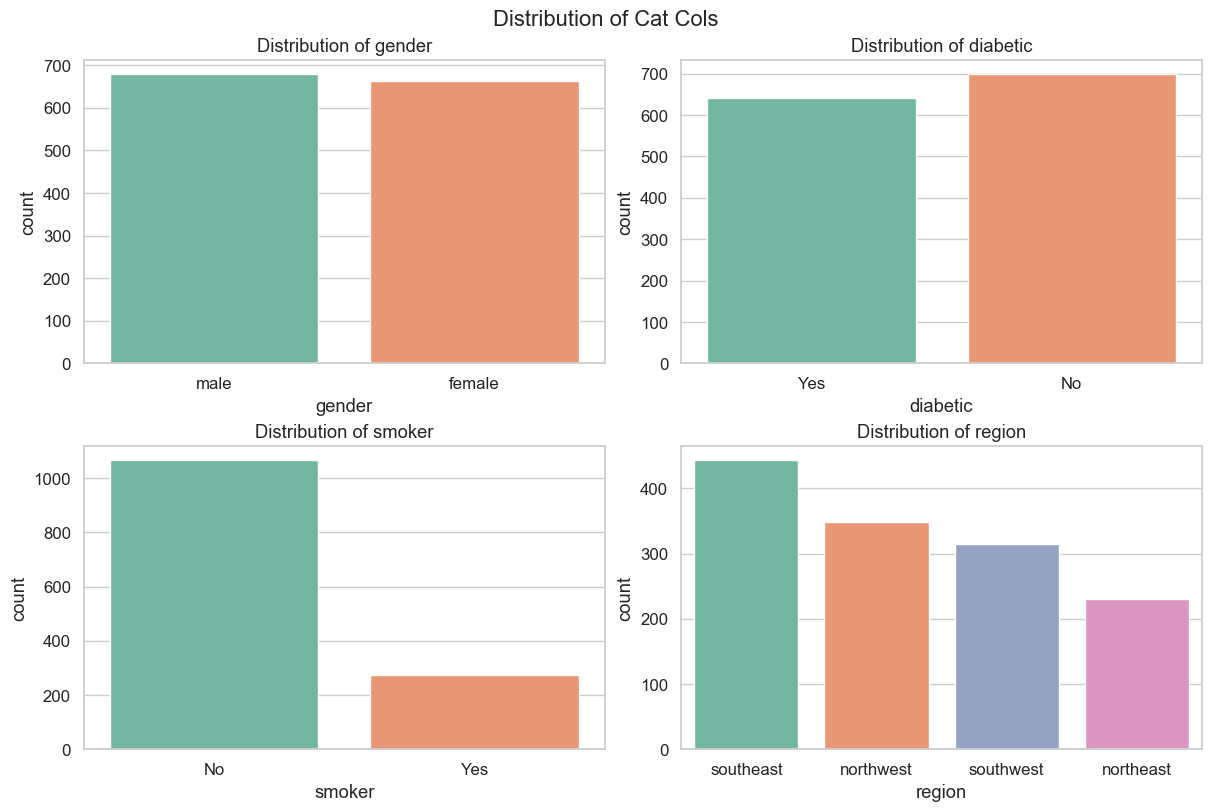

In [47]:
# Visualize the Distribution of categorical cols
cat_cols = ['gender', 'diabetic', 'smoker', 'region']

plt.figure(figsize=(12, 8), layout='constrained')

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, data=df, hue=col, legend=False)
    plt.title(f'Distribution of {col}')
plt.suptitle('Distribution of Cat Cols')
plt.show()

In [48]:
# Comparing average Claims by Gender & Smoking status 
# Using Standard Deviation (SD) to see variations in the distribution of Claims data
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8061.54
        Yes      33042.01
Name: claim, dtype: float64

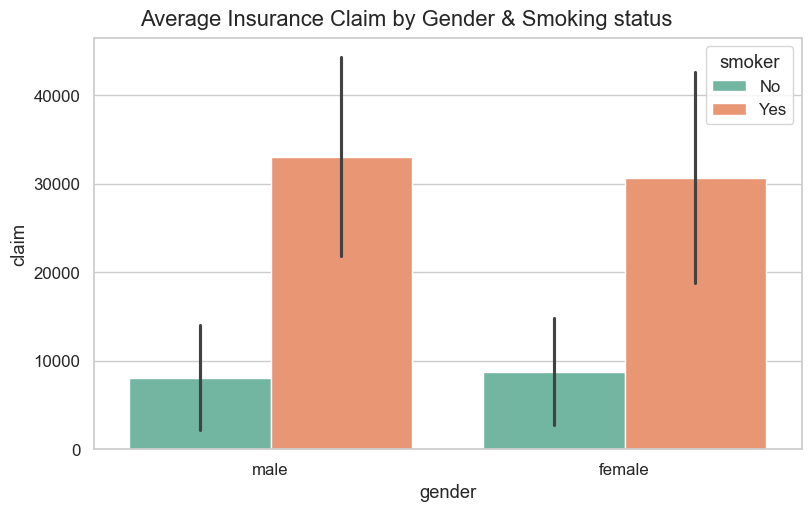

In [49]:
plt.figure(figsize=(8, 5), layout='constrained') 
sns.barplot(data=df, x='gender', y='claim', hue='smoker', estimator='mean', errorbar='sd')
plt.suptitle('Average Insurance Claim by Gender & Smoking status')
plt.show()

In [50]:
# See the average Claim by region & Diabetic status
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11335.48,12083.74
southeast,13578.72,12521.62
southwest,13069.91,12313.74


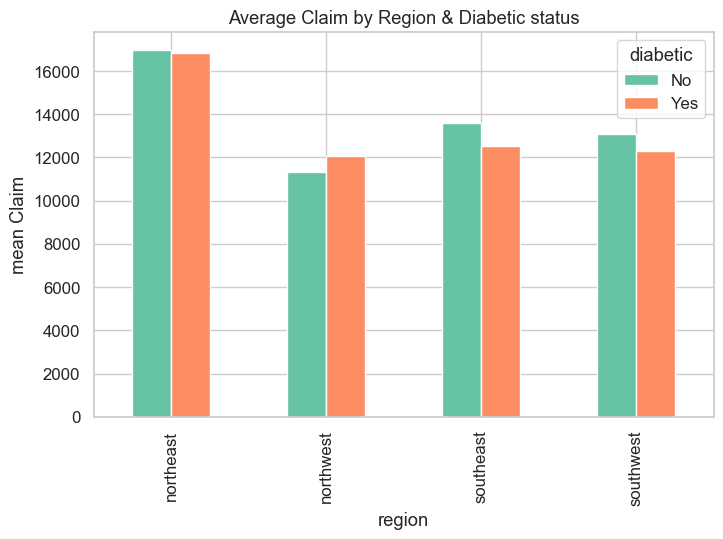

In [51]:
pivot_region_diabetic.plot(kind='bar', figsize=(8, 5))
plt.title('Average Claim by Region & Diabetic status')
plt.ylabel('mean Claim')
plt.show()

In [52]:
# See the average Claim by Region & Smoking status 
pivot_table = pd.pivot_table(df, values='claim', index='region', columns='smoker', aggfunc='mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,7980.83,30192.00
southeast,7426.22,34845.00
southwest,8294.75,32269.06


In [53]:
# See the average Claim by Children & Diabetic status
# NOTE: use same variable name just for save the memory usage.
pivot_table = pd.pivot_table(df, values='claim', index='children', columns='diabetic', aggfunc='mean')
pivot_table

diabetic,No,Yes
children,,
0,12846.24,11795.14
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [54]:
# See the Correlation betwen Numerical Cols 
df[numerical_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.07
claim,-0.03,0.20,0.53,0.07,1.00


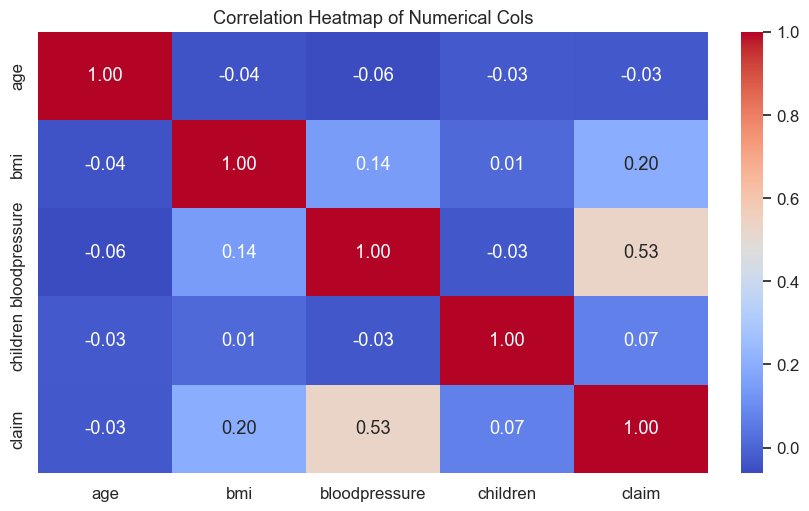

In [55]:
plt.figure(figsize=(8, 5), layout='constrained')
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Cols')
plt.show()

In [56]:
# Check Linear Cor
pearson_corr = df[numerical_cols].corr(method='pearson')['claim']

# Check Non-linear Cor
spearman_corr = df[numerical_cols].corr(method='spearman')['claim']

# Merge for comparison
comparison = pd.DataFrame({'Pearson (Linear)': pearson_corr, 'Spearman (Non-Linear)': spearman_corr})
print(comparison)

               Pearson (Linear)  Spearman (Non-Linear)
age                       -0.03                  -0.01
bmi                        0.20                   0.12
bloodpressure              0.53                   0.37
children                   0.07                   0.14
claim                      1.00                   1.00


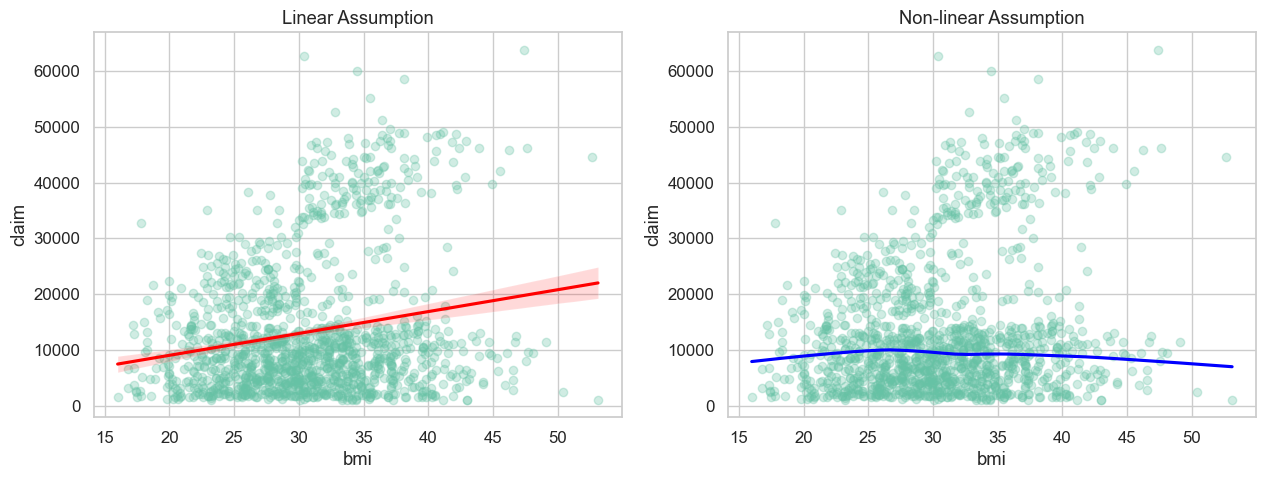

In [57]:
# Check Linear vs Non-linear realationship between BMI and Claim

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear (Pearson style)
sns.regplot(data=df, x='bmi', y='claim', ax=axes[0], 
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
axes[0].set_title('Linear Assumption')

# Non Linear (Spearmen style)
sns.regplot(data=df, x='bmi', y='claim', ax=axes[1], 
            lowess=True, line_kws={'color': 'blue'}, scatter_kws={'alpha': 0.3})
axes[1].set_title('Non-linear Assumption')

plt.show()

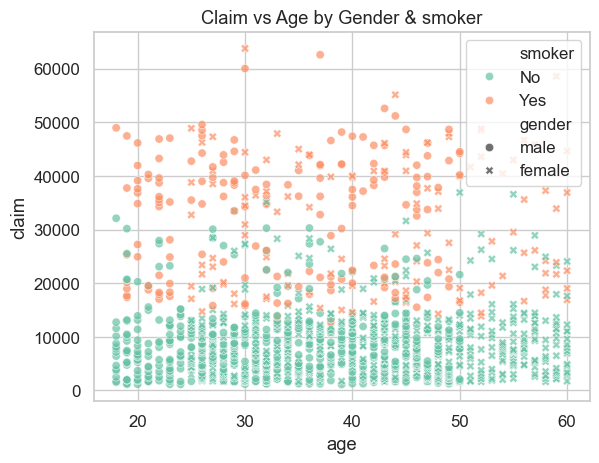

In [58]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker', style='gender', alpha=0.7)
plt.title('Claim vs Age by Gender & smoker')
plt.show()

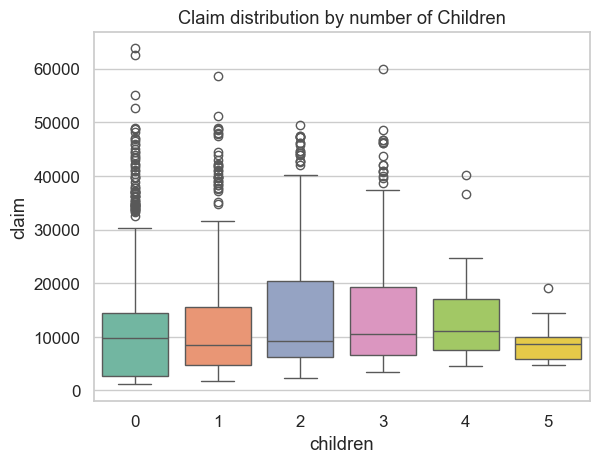

In [59]:
sns.boxplot(data=df, x='children', y='claim', hue='children', palette='Set2', legend=False)
plt.title('Claim distribution by number of Children')
plt.show()

In [60]:
# make new feature age_group for better analysis and modeling
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, 100], labels=['<18', '18-30', '31-45', '46-60', '60+'])

In [61]:
# Check the new feature
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group'],
      dtype='str')

In [62]:
df['age_group'].value_counts()

age_group
31-45    556
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

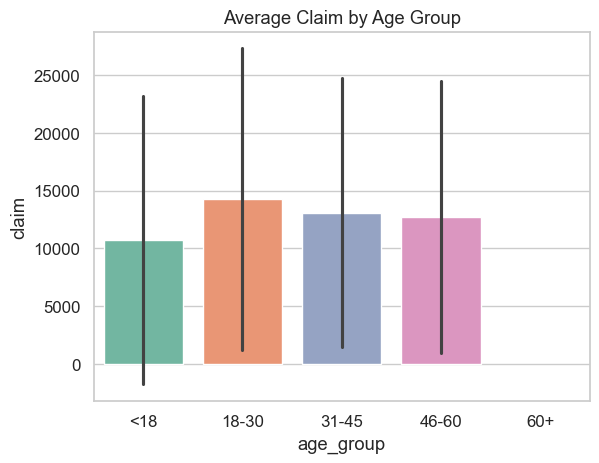

In [63]:
sns.barplot(data=df, x='age_group', y='claim', estimator='mean', errorbar='sd', hue='age_group', palette='Set2', legend=False, dodge=False)
plt.title('Average Claim by Age Group')
plt.show()

In [64]:
# New features: BMI Category for better analysis and modeling
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df['bmi_category'].value_counts()


bmi_category
Obese          708
Overweight     389
Normal         222
Underweight     21
Name: count, dtype: int64

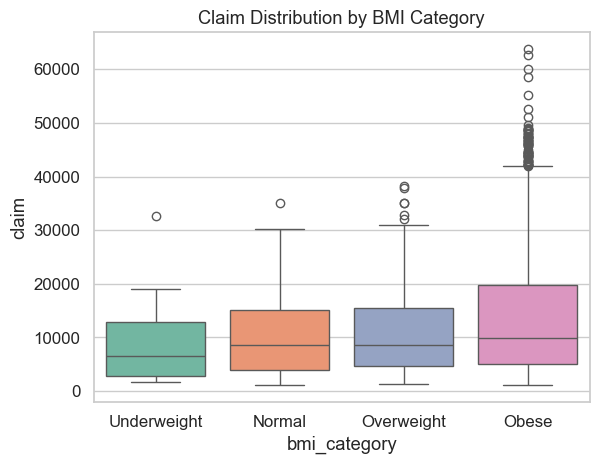

In [65]:
sns.boxplot(data=df, x='bmi_category', y='claim', palette='Set2', hue='bmi_category', dodge=False) # hue='smoker' for see the distribution of claim by smoking status
plt.title('Claim Distribution by BMI Category')
plt.show()

In [66]:
region_stats = df.groupby('region').agg(smoker_rate=('smoker', lambda x: (x=='Yes').mean() * 100),
                                         mean_claim=('claim', 'mean')).reset_index()

region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.62,11672.09
2,southeast,20.54,13058.52
3,southwest,18.47,12723.13


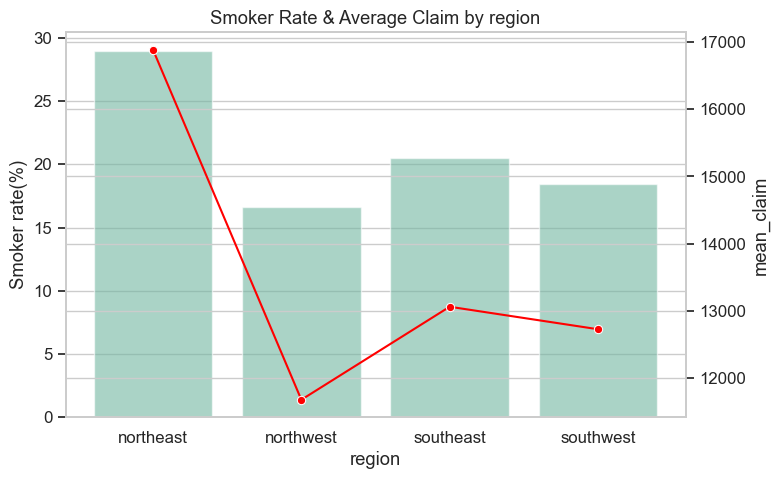

In [67]:
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(data=region_stats, x='region', y='smoker_rate', ax=ax1, alpha=0.6)

ax2= ax1.twinx()
sns.lineplot(data=region_stats, x='region', y='mean_claim', ax=ax2, color='red', marker='o')

ax1.set_ylabel('Smoker rate(%)')
ax2.set_xlabel('Average Claim($)')
plt.title('Smoker Rate & Average Claim by region')
plt.show()